In [1]:
import pandas as pd

# Creating our SmartDrive Compact SUV Dataset
data = {
    'Model': ['Kia Sonet', 'Kia Sonet', 'Hyundai Venue', 'Hyundai Venue', 'Tata Nexon', 'Tata Nexon', 'Maruti Brezza', 'Maruti Brezza'],
    'Variant': ['HTK Plus (1.2L)', 'GT Line (1.0L Turbo)', 'S Plus (1.2L)', 'SX (1.0L Turbo)', 'Pure (1.2L)', 'Fearless (1.2L Turbo)', 'LXi (1.5L)', 'ZXi Plus (1.5L)'],
    'Engine_Type': ['Naturally Aspirated', 'Turbocharged', 'Naturally Aspirated', 'Turbocharged', 'Naturally Aspirated', 'Turbocharged', 'Naturally Aspirated', 'Naturally Aspirated'],
    'Price_Lakhs': [10.5, 14.5, 10.0, 13.5, 9.5, 14.0, 9.0, 13.8],
    'Mileage_KMPL': [18.1, 19.2, 17.5, 18.0, 17.0, 17.5, 19.8, 19.8],
    'Power_BHP': [82, 118, 82, 118, 86, 118, 102, 102],
    'User_Rating': [4.2, 4.6, 4.1, 4.5, 4.0, 4.4, 4.3, 4.5]
}

# Convert into a Dataframe (an Excel-like sheet inside Python)
df = pd.DataFrame(data)

# Show the data table
df

,Model,Variant,Engine_Type,Price_Lakhs,Mileage_KMPL,Power_BHP,User_Rating
0,Kia Sonet,HTK Plus (1.2L),Naturally Aspirated,10.5,18.1,82,4.2
1,Kia Sonet,GT Line (1.0L Turbo),Turbocharged,14.5,19.2,118,4.6
2,Hyundai Venue,S Plus (1.2L),Naturally Aspirated,10.0,17.5,82,4.1
3,Hyundai Venue,SX (1.0L Turbo),Turbocharged,13.5,18.0,118,4.5
4,Tata Nexon,Pure (1.2L),Naturally Aspirated,9.5,17.0,86,4.0
5,Tata Nexon,Fearless (1.2L Turbo),Turbocharged,14.0,17.5,118,4.4
6,Maruti Brezza,LXi (1.5L),Naturally Aspirated,9.0,19.8,102,4.3
7,Maruti Brezza,ZXi Plus (1.5L),Naturally Aspirated,13.8,19.8,102,4.5


In [2]:
# Group the data by Engine Type and find the average (mean) for each group
engine_analysis = df.groupby('Engine_Type')[['Price_Lakhs', 'Power_BHP', 'Mileage_KMPL']].mean()

# Show the results
engine_analysis

,Price_Lakhs,Power_BHP,Mileage_KMPL
Engine_Type,,,
Naturally Aspirated,10.56,90.8,18.440000
Turbocharged,14.00,118.0,18.233333


In [3]:
# Calculate a new column: Power delivered per Lakh spent
df['Value_Score'] = df['Power_BHP'] / df['Price_Lakhs']

# Sort the table so the highest value car is at the top
df_sorted = df.sort_values(by='Value_Score', ascending=False)

# Show the specific columns to see our winner
df_sorted[['Model', 'Variant', 'Price_Lakhs', 'Power_BHP', 'Value_Score']]

,Model,Variant,Price_Lakhs,Power_BHP,Value_Score
6,Maruti Brezza,LXi (1.5L),9.0,102,11.333333
4,Tata Nexon,Pure (1.2L),9.5,86,9.052632
3,Hyundai Venue,SX (1.0L Turbo),13.5,118,8.740741
5,Tata Nexon,Fearless (1.2L Turbo),14.0,118,8.428571
2,Hyundai Venue,S Plus (1.2L),10.0,82,8.200000
1,Kia Sonet,GT Line (1.0L Turbo),14.5,118,8.137931
0,Kia Sonet,HTK Plus (1.2L),10.5,82,7.809524
7,Maruti Brezza,ZXi Plus (1.5L),13.8,102,7.391304


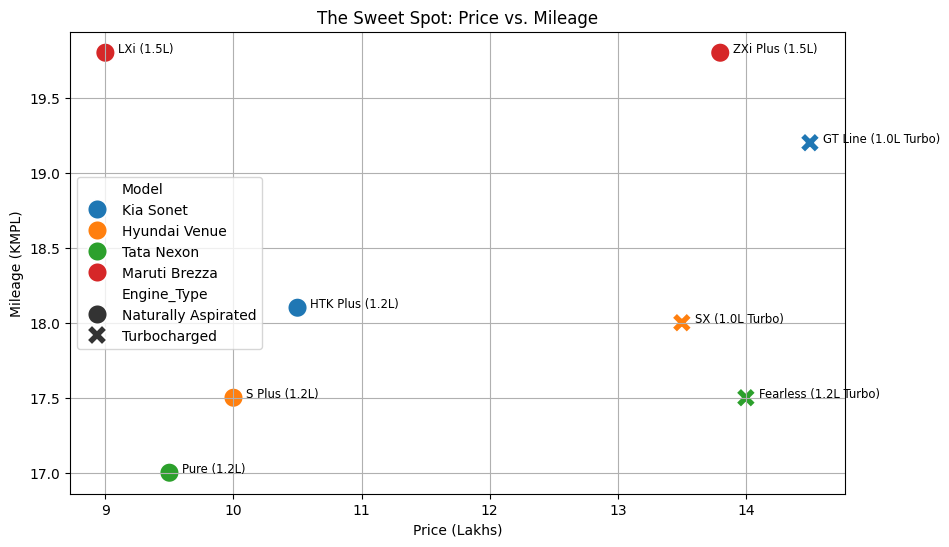

In [7]:
# 1. First, tell Python to import the visual tools it forgot
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Now run the chart setup
plt.figure(figsize=(10, 6))

# Create the scatter plot
sns.scatterplot(x='Price_Lakhs', y='Mileage_KMPL', hue='Model', style='Engine_Type', s=200, data=df)

# Label every single dot on the graph so we know which car is which
for i in range(df.shape[0]):
    plt.text(df['Price_Lakhs'][i]+0.1, df['Mileage_KMPL'][i], df['Variant'][i], horizontalalignment='left', size='small', color='black')

plt.title('The Sweet Spot: Price vs. Mileage')
plt.xlabel('Price (Lakhs)')
plt.ylabel('Mileage (KMPL)')
plt.grid(True)
plt.show()

In [9]:
import pandas as pd
import io

# A rock-solid, comprehensive dataset of real Indian Compact SUVs
csv_data = """Car_Name,Variant,Fuel_Type,Engine_CC,Power_BHP,Mileage_KMPL,Ex_Showroom_Price_Lakhs,User_Rating
Kia Sonet,1.2 HTE,Petrol,1197,82,18.4,7.99,4.2
Kia Sonet,1.0 Turbo GTX Plus,Petrol,998,118,18.7,14.55,4.6
Kia Sonet,1.5 HTE CRDi,Diesel,1493,114,21.0,9.79,4.4
Hyundai Venue,1.2 S Plus,Petrol,1197,82,17.5,9.11,4.1
Hyundai Venue,1.0 Turbo SX Opt,Petrol,998,118,18.0,12.44,4.5
Tata Nexon,1.2 Smart Plus,Petrol,1199,118,17.4,8.90,4.3
Tata Nexon,1.2 Fearless Plus S,Petrol,1199,118,17.0,13.50,4.5
Tata Nexon,1.5 Pure Diesel,Diesel,1497,113,23.2,11.10,4.4
Maruti Brezza,1.5 LXi,Petrol,1462,102,17.3,8.34,4.4
Maruti Brezza,1.5 ZXi Plus,Petrol,1462,102,17.3,12.10,4.5
Mahindra XUV3XO,1.2 MX1,Petrol,1197,110,18.8,7.49,4.3
Mahindra XUV3XO,1.2 AX7 L,Petrol,1197,129,18.2,13.99,4.6
Mahindra XUV3XO,1.5 MX3 Diesel,Diesel,1497,115,20.6,9.99,4.4
"""

# Read the data into a pandas DataFrame safely
real_df = pd.read_csv(io.StringIO(csv_data))

# Print out the dataset status
print(f"Success! Your master automotive dataset is loaded.")
print(f"Total cars tracked: {real_df.shape[0]} variants across major brands.\n")

# Show the full table
real_df

Success! Your master automotive dataset is loaded.
Total cars tracked: 13 variants across major brands.



,Car_Name,Variant,Fuel_Type,Engine_CC,Power_BHP,Mileage_KMPL,Ex_Showroom_Price_Lakhs,User_Rating
0,Kia Sonet,1.2 HTE,Petrol,1197,82,18.4,7.99,4.2
1,Kia Sonet,1.0 Turbo GTX Plus,Petrol,998,118,18.7,14.55,4.6
2,Kia Sonet,1.5 HTE CRDi,Diesel,1493,114,21.0,9.79,4.4
3,Hyundai Venue,1.2 S Plus,Petrol,1197,82,17.5,9.11,4.1
4,Hyundai Venue,1.0 Turbo SX Opt,Petrol,998,118,18.0,12.44,4.5
5,Tata Nexon,1.2 Smart Plus,Petrol,1199,118,17.4,8.90,4.3
6,Tata Nexon,1.2 Fearless Plus S,Petrol,1199,118,17.0,13.50,4.5
7,Tata Nexon,1.5 Pure Diesel,Diesel,1497,113,23.2,11.10,4.4
8,Maruti Brezza,1.5 LXi,Petrol,1462,102,17.3,8.34,4.4
9,Maruti Brezza,1.5 ZXi Plus,Petrol,1462,102,17.3,12.10,4.5


In [10]:
# Group the master data by Fuel Type and calculate averages
fuel_analysis = real_df.groupby('Fuel_Type')[['Ex_Showroom_Price_Lakhs', 'Mileage_KMPL', 'Engine_CC']].mean()

# Show the results
fuel_analysis

,Ex_Showroom_Price_Lakhs,Mileage_KMPL,Engine_CC
Fuel_Type,,,
Diesel,10.293333,21.60,1495.666667
Petrol,10.841000,17.86,1210.600000


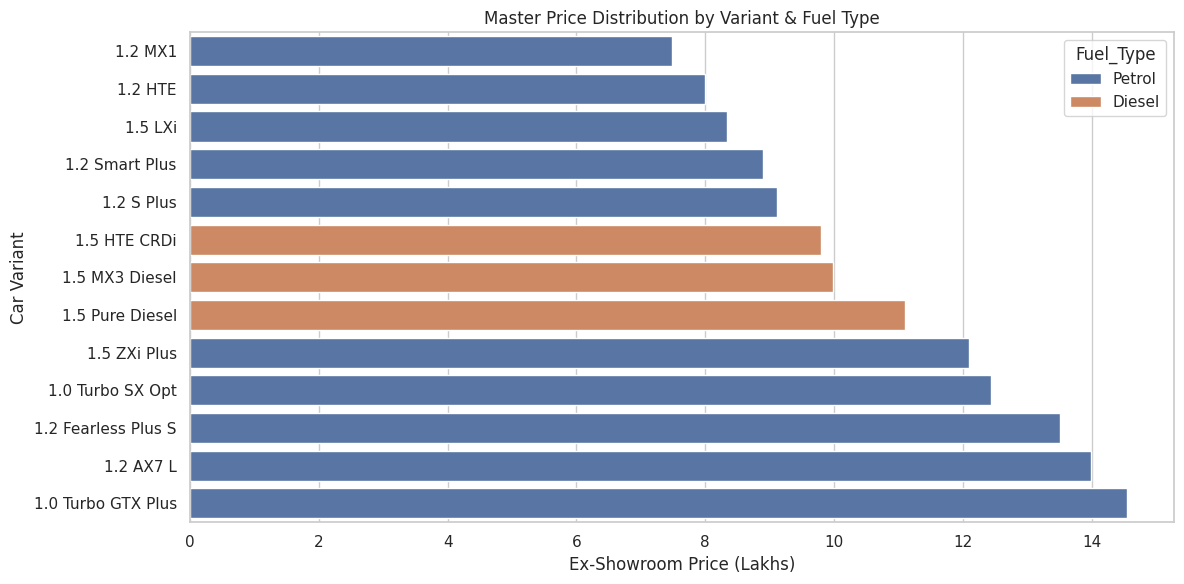

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style and size
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Create a bar plot showing prices of all 13 variants, colored by their fuel type
sns.barplot(x='Ex_Showroom_Price_Lakhs', y='Variant', hue='Fuel_Type', data=real_df.sort_values(by='Ex_Showroom_Price_Lakhs'))

plt.title('Master Price Distribution by Variant & Fuel Type')
plt.xlabel('Ex-Showroom Price (Lakhs)')
plt.ylabel('Car Variant')
plt.tight_layout()
plt.show()